# Importing of Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Data Loading

In [2]:
df = pd.read_csv(r".\Datasets\diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# Data Cleaning

In [3]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
for i in df.columns: print(i, ':\n', df[i].unique())

Pregnancies :
 [ 6  1  8  0  5  3 10  2  4  7  9 11 13 15 17 12 14]
Glucose :
 [148  85 183  89 137 116  78 115 197 125 110 168 139 189 166 100 118 107
 103 126  99 196 119 143 147  97 145 117 109 158  88  92 122 138 102  90
 111 180 133 106 171 159 146  71 105 101 176 150  73 187  84  44 141 114
  95 129  79   0  62 131 112 113  74  83 136  80 123  81 134 142 144  93
 163 151  96 155  76 160 124 162 132 120 173 170 128 108 154  57 156 153
 188 152 104  87  75 179 130 194 181 135 184 140 177 164  91 165  86 193
 191 161 167  77 182 157 178  61  98 127  82  72 172  94 175 195  68 186
 198 121  67 174 199  56 169 149  65 190]
BloodPressure :
 [ 72  66  64  40  74  50   0  70  96  92  80  60  84  30  88  90  94  76
  82  75  58  78  68 110  56  62  85  86  48  44  65 108  55 122  54  52
  98 104  95  46 102 100  61  24  38 106 114]
SkinThickness :
 [35 29  0 23 32 45 19 47 38 30 41 33 26 15 36 11 31 37 42 25 18 24 39 27
 21 34 10 60 13 20 22 28 54 40 51 56 14 17 50 44 12 46 16  7 52 43 48

In [8]:
for i in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']: print(df[i][df[i] == 0].value_counts())

Glucose
0    5
Name: count, dtype: int64
BloodPressure
0    35
Name: count, dtype: int64
SkinThickness
0    227
Name: count, dtype: int64
Insulin
0    374
Name: count, dtype: int64
BMI
0.0    11
Name: count, dtype: int64


In [9]:
for i in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']: df[i].replace([0], df[i].mean(), inplace = True)

In [10]:
for i in df.columns: print(i, ':\n', df[i].unique())

Pregnancies :
 [ 6  1  8  0  5  3 10  2  4  7  9 11 13 15 17 12 14]
Glucose :
 [148.          85.         183.          89.         137.
 116.          78.         115.         197.         125.
 110.         168.         139.         189.         166.
 100.         118.         107.         103.         126.
  99.         196.         119.         143.         147.
  97.         145.         117.         109.         158.
  88.          92.         122.         138.         102.
  90.         111.         180.         133.         106.
 171.         159.         146.          71.         105.
 101.         176.         150.          73.         187.
  84.          44.         141.         114.          95.
 129.          79.         120.89453125  62.         131.
 112.         113.          74.          83.         136.
  80.         123.          81.         134.         142.
 144.          93.         163.         151.          96.
 155.          76.         160.         124.       

In [11]:
for i in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']: print(df[i][df[i] == 0].value_counts())

Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)


# Data Analysis

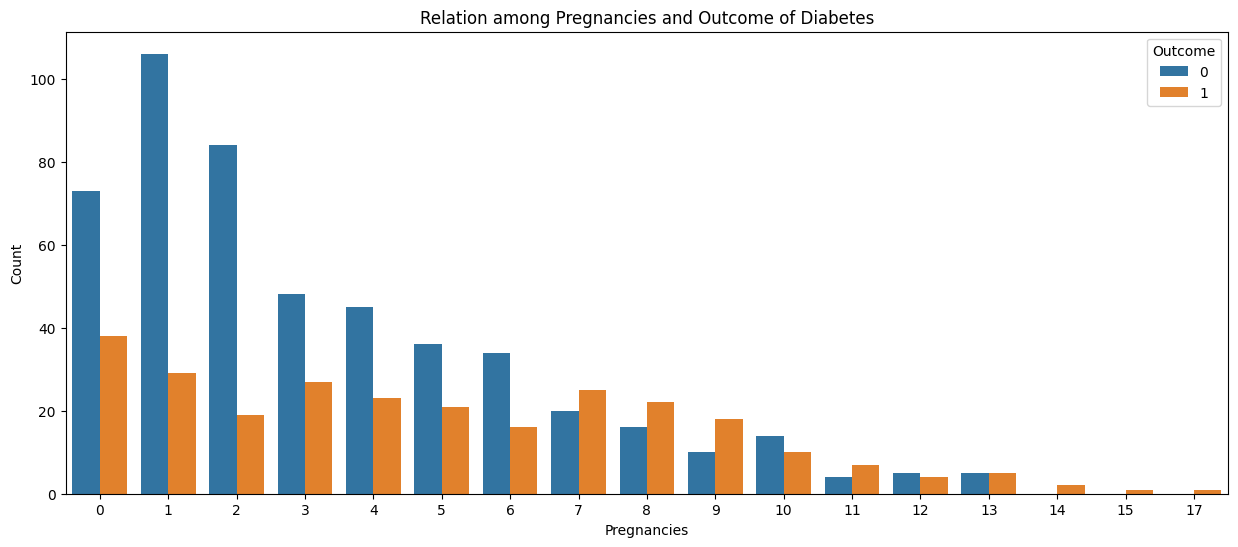

In [12]:
plt.figure(figsize = (15,6))
sns.countplot(x = df.Pregnancies, hue = df.Outcome)
plt.title('Relation among Pregnancies and Outcome of Diabetes')
plt.ylabel('Count')
plt.show()

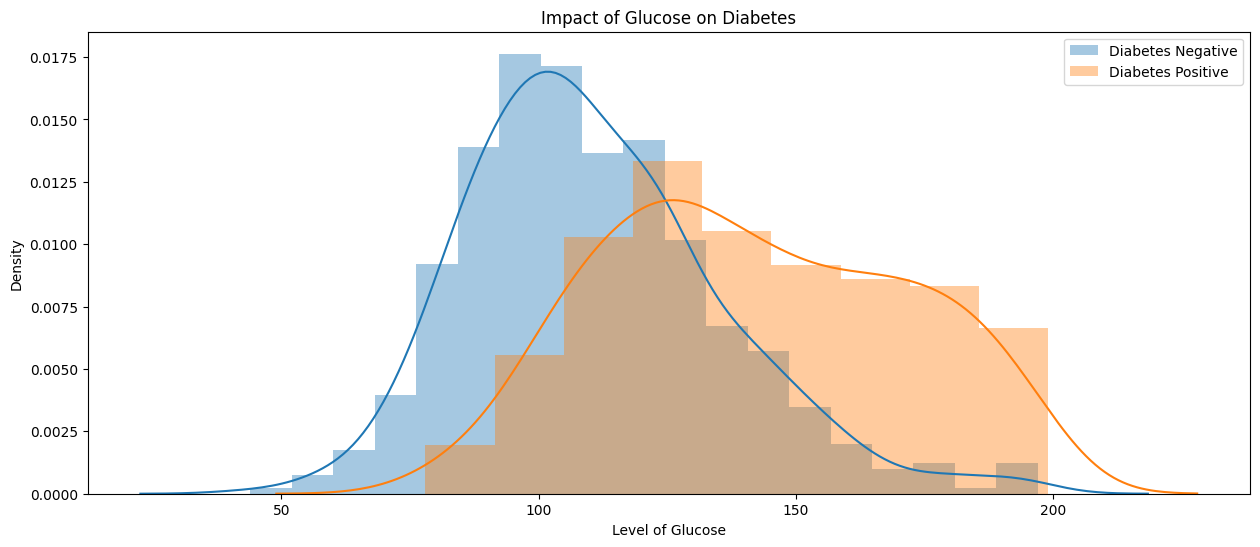

In [13]:
plt.figure(figsize = (15,6))
sns.distplot(df.Glucose[df.Outcome == 0], label = 'Diabetes Negative')
sns.distplot(df.Glucose[df.Outcome == 1], label = 'Diabetes Positive')
plt.title('Impact of Glucose on Diabetes')
plt.xlabel('Level of Glucose')
plt.legend()
plt.show()

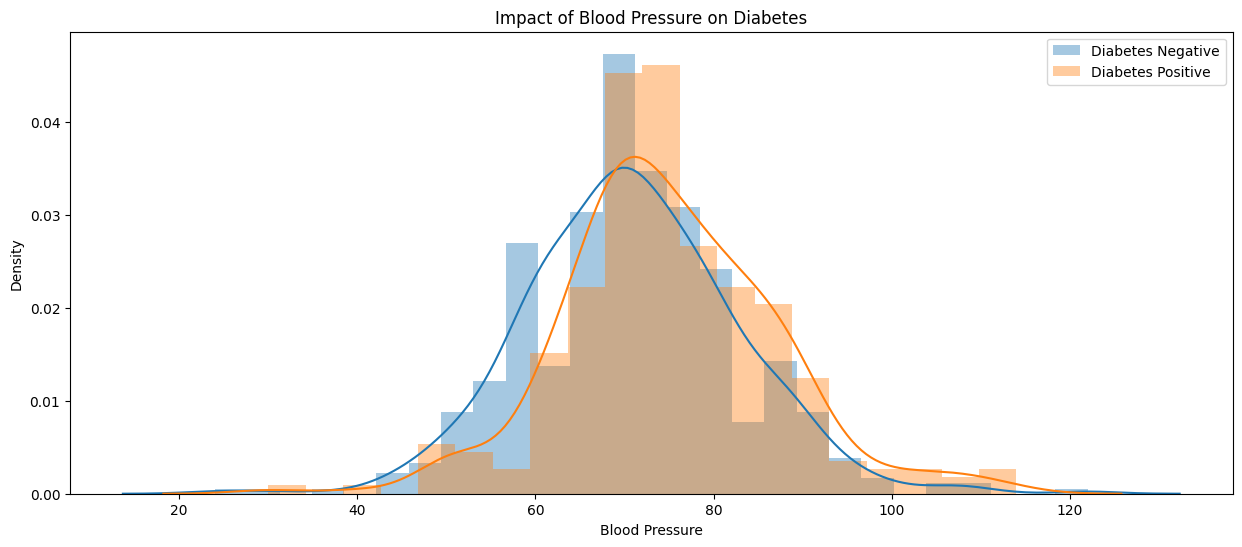

In [14]:
plt.figure(figsize = (15,6))
sns.distplot(df.BloodPressure[df.Outcome == 0], label = 'Diabetes Negative')
sns.distplot(df.BloodPressure[df.Outcome == 1], label = 'Diabetes Positive')
plt.title('Impact of Blood Pressure on Diabetes')
plt.xlabel('Blood Pressure')
plt.legend()
plt.show()

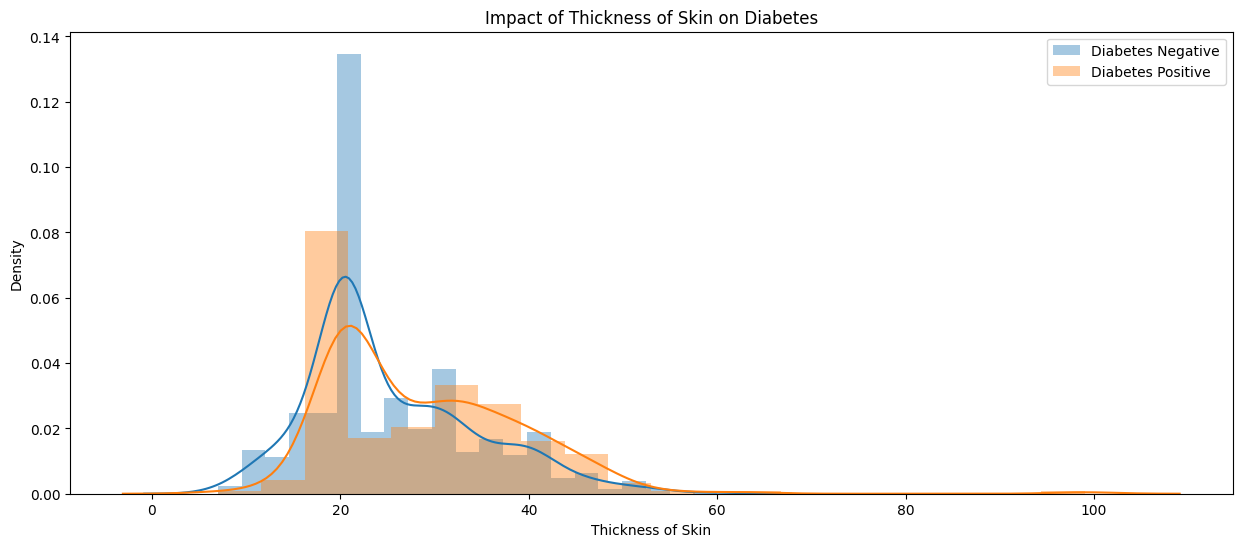

In [15]:
plt.figure(figsize = (15,6))
sns.distplot(df.SkinThickness[df.Outcome == 0], label = 'Diabetes Negative')
sns.distplot(df.SkinThickness[df.Outcome == 1], label = 'Diabetes Positive')
plt.title('Impact of Thickness of Skin on Diabetes')
plt.xlabel('Thickness of Skin')
plt.legend()
plt.show()

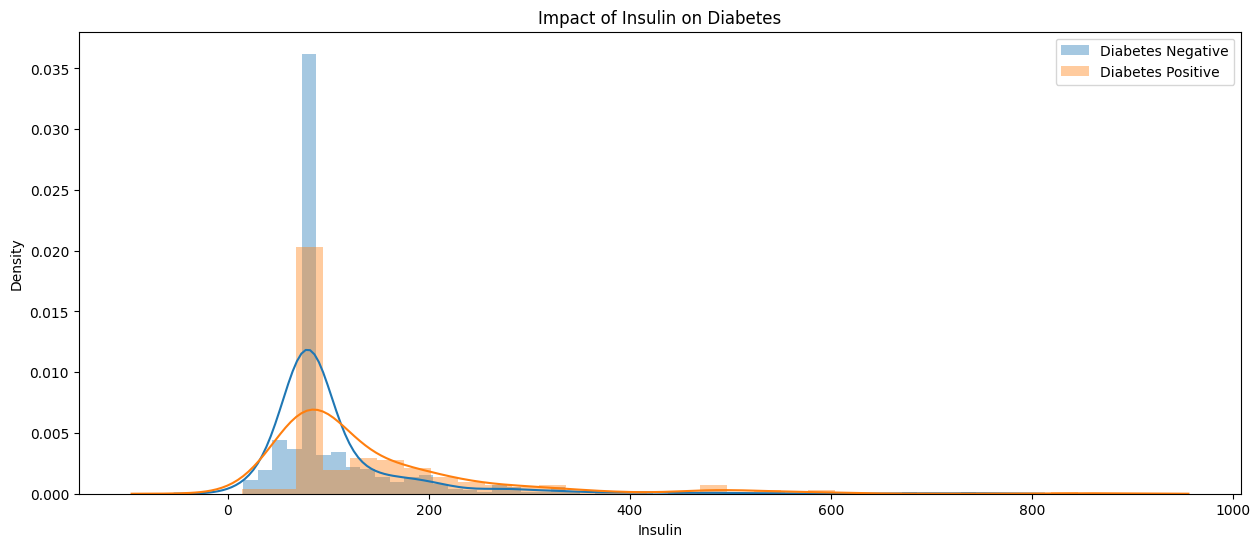

In [16]:
plt.figure(figsize = (15,6))
sns.distplot(df.Insulin[df.Outcome == 0], label = 'Diabetes Negative')
sns.distplot(df.Insulin[df.Outcome == 1], label = 'Diabetes Positive')
plt.title('Impact of Insulin on Diabetes')
plt.legend()
plt.show()

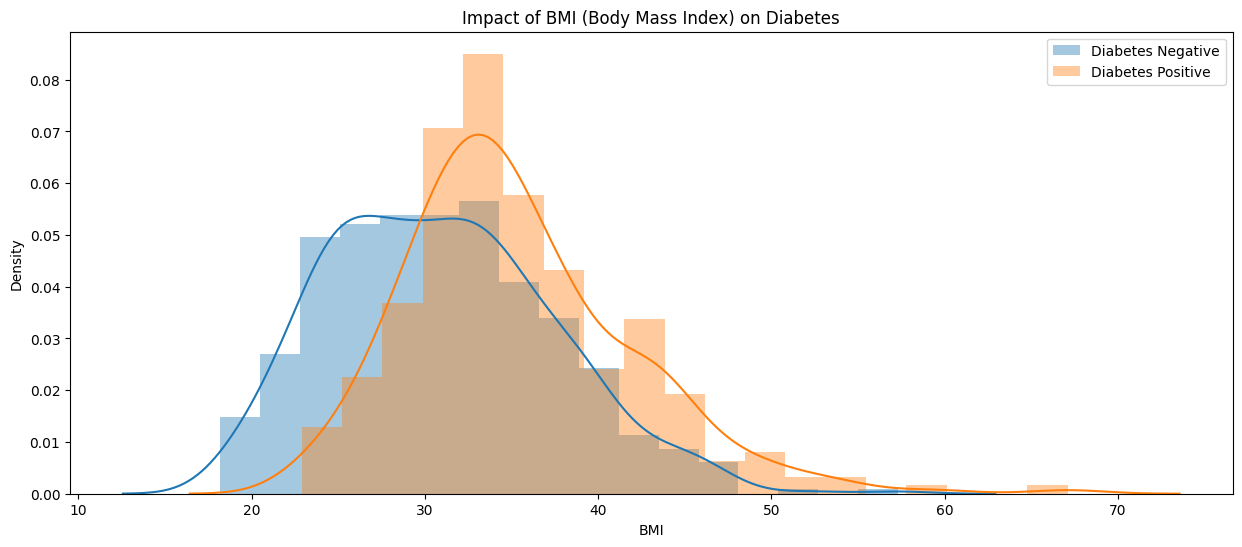

In [17]:
plt.figure(figsize = (15,6))
sns.distplot(df.BMI[df.Outcome == 0], label = 'Diabetes Negative')
sns.distplot(df.BMI[df.Outcome == 1], label = 'Diabetes Positive')
plt.title('Impact of BMI (Body Mass Index) on Diabetes')
plt.legend()
plt.show()

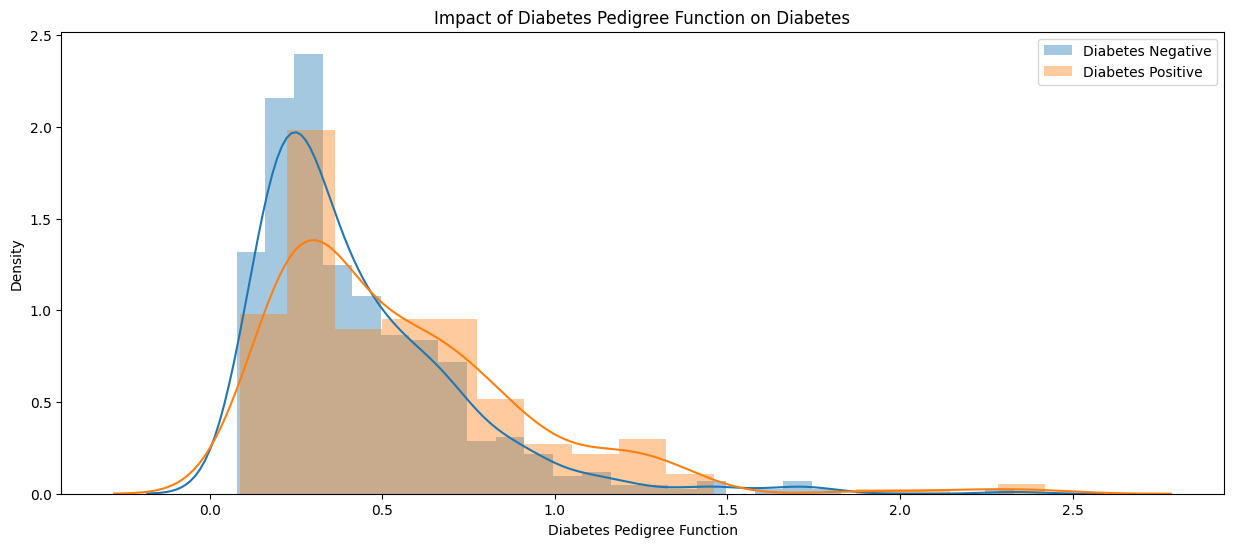

In [18]:
plt.figure(figsize = (15,6))
sns.distplot(df.DiabetesPedigreeFunction[df.Outcome == 0], label = 'Diabetes Negative')
sns.distplot(df.DiabetesPedigreeFunction[df.Outcome == 1], label = 'Diabetes Positive')
plt.title('Impact of Diabetes Pedigree Function on Diabetes')
plt.xlabel('Diabetes Pedigree Function')
plt.legend()
plt.show()

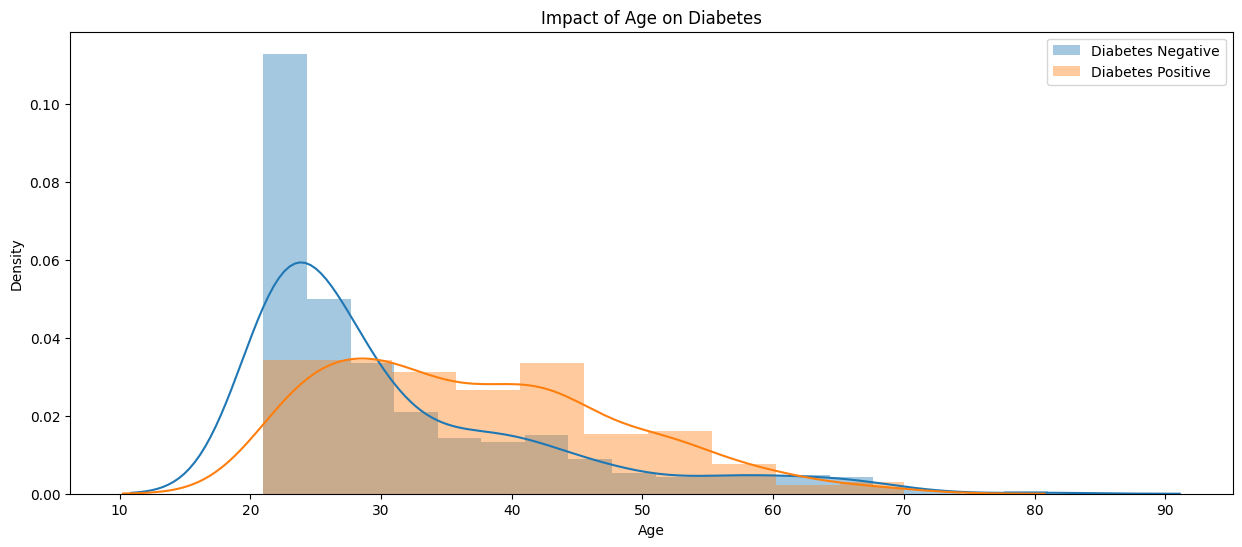

In [19]:
plt.figure(figsize = (15,6))
sns.distplot(df.Age[df.Outcome == 0], label = 'Diabetes Negative')
sns.distplot(df.Age[df.Outcome == 1], label = 'Diabetes Positive')
plt.title('Impact of Age on Diabetes')
plt.legend()
plt.show()

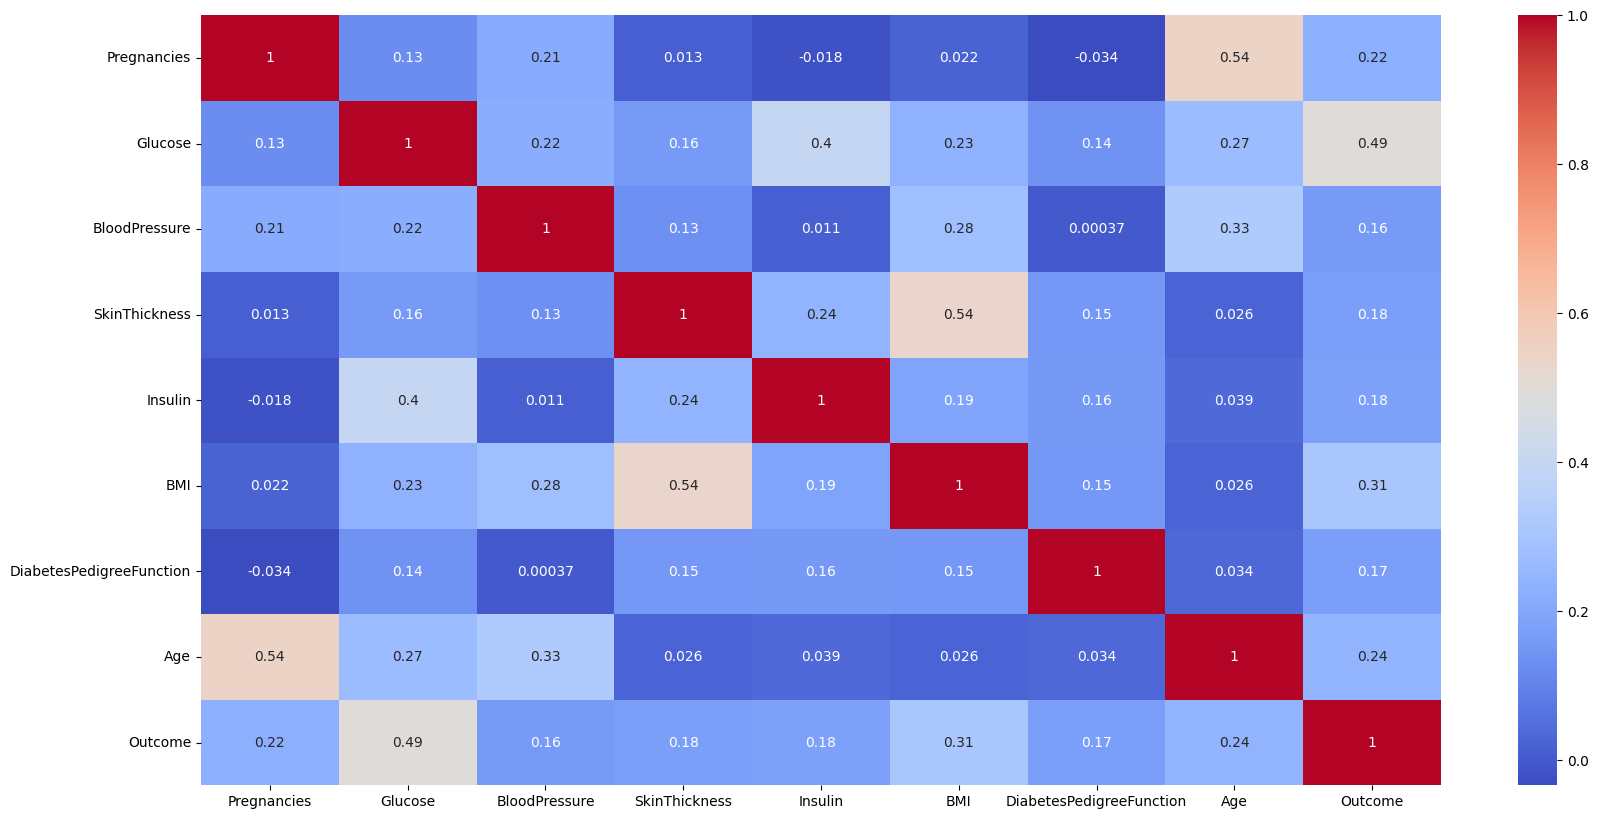

In [20]:
plt.figure(figsize = (20,10))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.yticks(rotation = 0)
plt.show()

# Input and Output

In [21]:
ip = df.drop(['Outcome', 'BloodPressure'], axis = 1)
ip

,Pregnancies,Glucose,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,35.000000,79.799479,33.6,0.627,50
1,1,85.0,29.000000,79.799479,26.6,0.351,31
2,8,183.0,20.536458,79.799479,23.3,0.672,32
3,1,89.0,23.000000,94.000000,28.1,0.167,21
4,0,137.0,35.000000,168.000000,43.1,2.288,33
...,...,...,...,...,...,...,...
763,10,101.0,48.000000,180.000000,32.9,0.171,63
764,2,122.0,27.000000,79.799479,36.8,0.340,27
765,5,121.0,23.000000,112.000000,26.2,0.245,30
766,1,126.0,20.536458,79.799479,30.1,0.349,47


In [22]:
op = df['Outcome']
op

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

# Train Test Split

In [23]:
x_train, x_test, y_train, y_test = train_test_split(ip, op, train_size = 0.7)
df.shape, x_train.shape, x_test.shape

((768, 9), (537, 7), (231, 7))

# Standard Scaler

In [24]:
sc = StandardScaler()
sc

StandardScaler()

In [25]:
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

# Logistic Regression

In [26]:
log = LogisticRegression()
log.fit(x_train, y_train)

LogisticRegression()

In [27]:
ycap = log.predict(x_test)
ycap

array([0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1], dtype=int64)

In [28]:
cm = confusion_matrix(ycap, y_test)
pd.DataFrame(cm)

,0,1
0,135,32
1,23,41


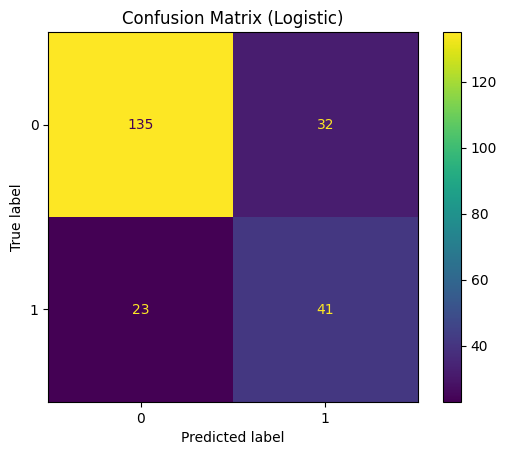

In [29]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.title('Confusion Matrix (Logistic)')
plt.show()

In [30]:
acs = accuracy_score(ycap, y_test)
rcs = recall_score(ycap, y_test)
prs = precision_score(ycap, y_test)
f1s = f1_score(ycap, y_test)
acs, rcs, prs, f1s

(0.7619047619047619, 0.640625, 0.5616438356164384, 0.5985401459854014)

# Gaussian Naive Bayes

In [31]:
gb = GaussianNB()
gb.fit(x_train, y_train)

GaussianNB()

In [32]:
ycap1 = gb.predict(x_test)
ycap1

array([0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1], dtype=int64)

In [33]:
acs1 = accuracy_score(ycap1, y_test)
rcs1 = recall_score(ycap1, y_test)
prs1 = precision_score(ycap1, y_test)
f1s1 = f1_score(ycap1, y_test)
acs1, rcs1, prs1, f1s1

(0.7532467532467533,
 0.6052631578947368,
 0.6301369863013698,
 0.6174496644295302)

In [34]:
cm1 = confusion_matrix(ycap1, y_test)
pd.DataFrame(cm1)

,0,1
0,128,27
1,30,46


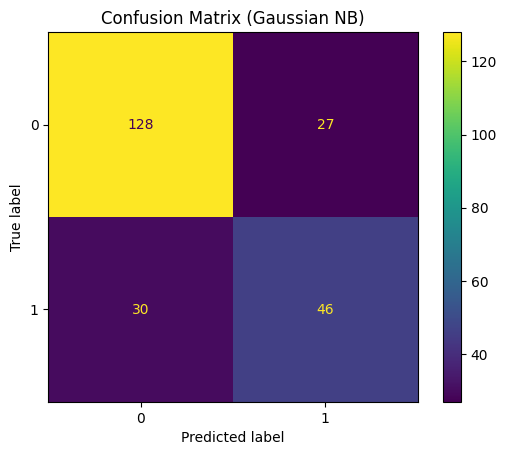

In [35]:
cmd1 = ConfusionMatrixDisplay(cm1)
cmd1.plot()
plt.title('Confusion Matrix (Gaussian NB)')
plt.show()

# K Nearest Neighbors

In [36]:
knn = KNeighborsClassifier(n_neighbors = 4)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=4)

In [37]:
ycap2 = knn.predict(x_test)
ycap2

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1], dtype=int64)

In [38]:
acs2 = accuracy_score(ycap2, y_test)
rcs2 = recall_score(ycap2, y_test)
prs2 = precision_score(ycap2, y_test)
f1s2 = f1_score(ycap2, y_test)
acs2, rcs2, prs2, f1s2

(0.7316017316017316,
 0.6078431372549019,
 0.4246575342465753,
 0.4999999999999999)

In [39]:
cm2 = confusion_matrix(ycap2, y_test)
pd.DataFrame(cm2)

,0,1
0,138,42
1,20,31


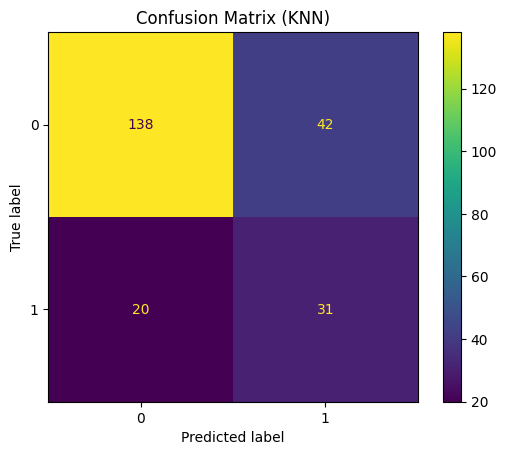

In [40]:
cmd2 = ConfusionMatrixDisplay(cm2)
cmd2.plot()
plt.title('Confusion Matrix (KNN)')
plt.show()

# Support Vector Machine

In [41]:
sv = svm.SVC(kernel = 'rbf', C = 100, gamma = 0.002)
sv.fit(x_train, y_train)

SVC(C=100, gamma=0.002)

In [42]:
ycap3 = sv.predict(x_test)
ycap3

array([0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1], dtype=int64)

In [43]:
acs3 = accuracy_score(ycap3, y_test)
rcs3 = recall_score(ycap3, y_test)
prs3 = precision_score(ycap3, y_test)
f1s3 = f1_score(ycap3, y_test)
acs3, rcs3, prs3, f1s3

(0.7532467532467533,
 0.6333333333333333,
 0.5205479452054794,
 0.5714285714285714)

In [44]:
cm3 = confusion_matrix(ycap3, y_test)
pd.DataFrame(cm3)

,0,1
0,136,35
1,22,38


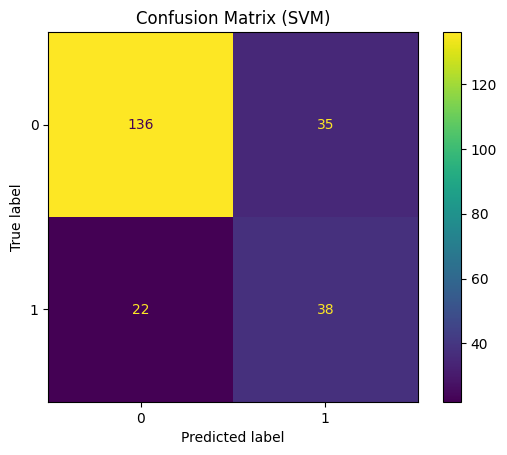

In [45]:
cmd3 = ConfusionMatrixDisplay(cm3)
cmd3.plot()
plt.title('Confusion Matrix (SVM)')
plt.show()

# Prediction

In [46]:
pdf = pd.DataFrame({'y':list(y_test),
                    'Prediction (Logistic)':ycap,
                    'Prediction (Gaussian NB)':ycap1,
                    'Prediction (KNN)':ycap2,
                    'Prediction (SVM)':ycap3})
pdf

,y,Prediction (Logistic),Prediction (Gaussian NB),Prediction (KNN),Prediction (SVM)
0,0,0,0,0,0
1,0,0,0,0,0
2,0,0,0,0,0
3,1,1,1,0,1
4,0,0,0,0,0
...,...,...,...,...,...
226,0,0,0,0,0
227,0,0,0,0,0
228,0,0,0,0,0
229,0,1,1,1,1


# Metrics

In [47]:
print("Accuracy Score (Logistic):\t", acs)
print("Accuracy Score (Gaussian NB):\t", acs1)
print("Accuracy Score (KNN):\t\t", acs2)
print("Accuracy Score (SVM):\t\t", acs3)

print("\nRecall Score (Logistic):\t", rcs)
print("Recall Score (Gaussian NB):\t", rcs1)
print("Recall Score (KNN):\t\t", rcs2)
print("Recall Score (SVM):\t\t", rcs3)

print("\nPrecision Score (Logistic):\t", prs)
print("Precision Score (Gaussian NB):\t", prs1)
print("Precision Score (KNN):\t\t", prs2)
print("Precision Score (SVM):\t\t", prs3)

print("\nF1 Score (Logistic):\t\t", f1s)
print("F1 Score (Gaussian NB):\t\t", f1s1)
print("F1 Score (KNN):\t\t\t", f1s2)
print("F1 Score (SVM):\t\t\t", f1s3)

Accuracy Score (Logistic):	 0.7619047619047619
Accuracy Score (Gaussian NB):	 0.7532467532467533
Accuracy Score (KNN):		 0.7316017316017316
Accuracy Score (SVM):		 0.7532467532467533

Recall Score (Logistic):	 0.640625
Recall Score (Gaussian NB):	 0.6052631578947368
Recall Score (KNN):		 0.6078431372549019
Recall Score (SVM):		 0.6333333333333333

Precision Score (Logistic):	 0.5616438356164384
Precision Score (Gaussian NB):	 0.6301369863013698
Precision Score (KNN):		 0.4246575342465753
Precision Score (SVM):		 0.5205479452054794

F1 Score (Logistic):		 0.5985401459854014
F1 Score (Gaussian NB):		 0.6174496644295302
F1 Score (KNN):			 0.4999999999999999
F1 Score (SVM):			 0.5714285714285714
